#  Skill-Based Job Role Predictor
### Machine Learning Project | Supervised Classification

**Goal:** Predict a job role from a candidate's skills, qualification and experience level  
**Approach:** Deep EDA → Feature Engineering → Multiple ML Models → Model Comparison → Save Best Model

---
## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Data Loading & Basic Info](#2-data-loading--basic-info)
3. [Deep EDA](#3-deep-eda)
   - 3.1 Target Distribution
   - 3.2 Experience Level Analysis
   - 3.3 Qualification Analysis
   - 3.4 Skills Analysis (NLP-based)
   - 3.5 Cross-Feature Analysis
   - 3.6 Skill Co-occurrence Heatmap
4. [Data Cleaning & Preprocessing](#4-data-cleaning--preprocessing)
5. [Feature Engineering](#5-feature-engineering)
6. [Model Training & Evaluation](#6-model-training--evaluation)
   - Random Forest
   - Gradient Boosting
   - XGBoost
   - LightGBM
   - Logistic Regression (baseline)
   - SVM
7. [Model Comparison](#7-model-comparison)
8. [Best Model Analysis](#8-best-model-analysis)
9. [Save Best Model](#9-save-best-model)

## 1. Setup & Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from itertools import combinations

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("+ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("-  XGBoost not installed — run: pip install xgboost")

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
    print("+ LightGBM available")
except ImportError:
    LGBM_AVAILABLE = False
    print("- LightGBM not installed — run: pip install lightgbm")

# Model persistence
import joblib
import pickle
import os

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

PALETTE = 'viridis'
RANDOM_STATE = 42

print("\n+ All core imports successful")

+ XGBoost available
+ LightGBM available

+ All core imports successful


## 2. Data Loading & Basic Info

In [42]:
import os

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_PATH = os.path.join(BASE_DIR, 'candidate_job_role_dataset.csv')

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (1000, 5)


,candidate_id,skills,qualification,experience_level,job_role
0,1,"Python, SQL, TensorFlow, Machine Learning, Com...",Master's in Data Science,Senior,Data Scientist
1,2,"HTML, CSS, JavaScript, React, Teamwork",Bachelor's in Computer Science,Mid,Frontend Developer
2,3,"Java, Spring, SQL, REST APIs, Problem Solving",Bachelor's in Software Engineering,Senior,Backend Developer
3,4,"Figma, Adobe XD, UI/UX Design, Creativity",Bachelor's in Design,Entry,Designer
4,5,"Python, Django, JavaScript, React, Agile",Master's in Computer Science,Mid,Full Stack Python Developer
5,6,"Financial Modeling, Excel, Communication, Risk...",Master's in Finance,Senior,Finance
6,7,"C++, Unreal Engine, Game Design, Teamwork",Bachelor's in Game Development,Mid,Game Developer
7,8,"Kubernetes, Docker, AWS, CI/CD, Linux",Bachelor's in Computer Science,Senior,DevOps Engineer
8,9,"Java, Spring Boot, Hibernate, Microservices",Bachelor's in Software Engineering,Mid,Full Stack Java Developer
9,10,"Solidity, Ethereum, JavaScript, Blockchain",Bachelor's in Computer Science,Entry,Blockchain Developer


In [44]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nRows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nColumn dtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicated rows:", df.duplicated().sum())

DATASET OVERVIEW

Rows: 1000, Columns: 5

Column dtypes:
candidate_id         int64
skills              object
qualification       object
experience_level    object
job_role            object
dtype: object

Missing values:
candidate_id        0
skills              0
qualification       0
experience_level    0
job_role            0
dtype: int64

Duplicated rows: 0


In [45]:
print("Unique counts per column:")
for col in df.columns:
    print(f"  {col:30s}: {df[col].nunique()} unique values")

Unique counts per column:
  candidate_id                  : 1000 unique values
  skills                        : 98 unique values
  qualification                 : 17 unique values
  experience_level              : 4 unique values
  job_role                      : 22 unique values


## 3. Deep EDA
### 3.1 Target Distribution — Job Roles

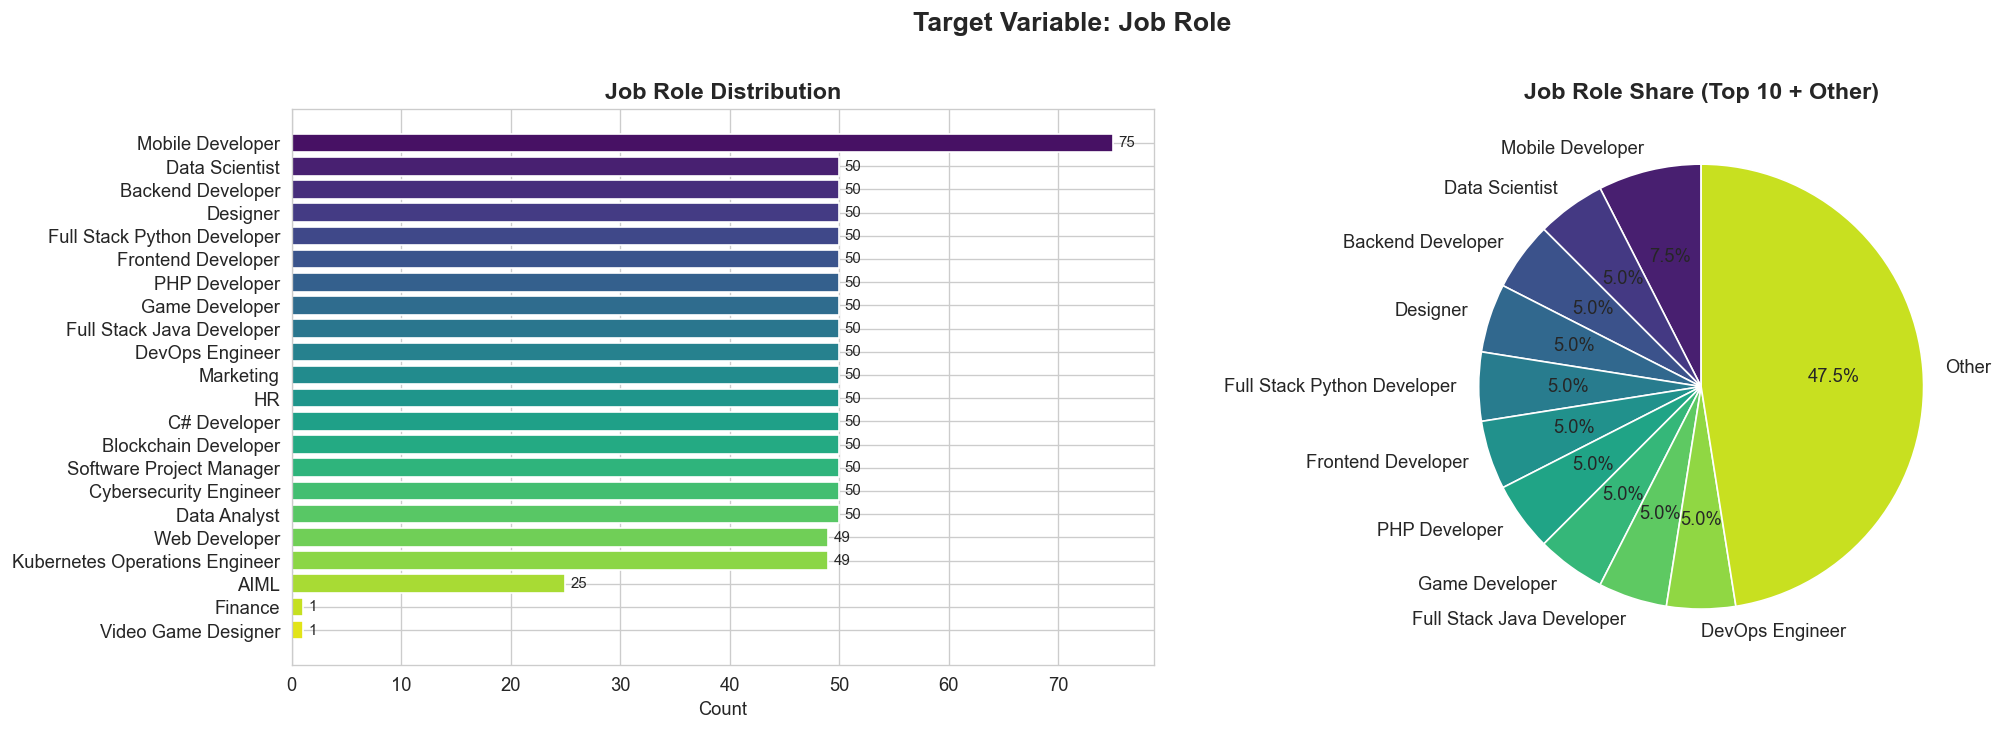


Class balance analysis:
  Max class: Mobile Developer (75 samples)
  Min class: Finance (1 samples)
  Imbalance ratio (max/min): 75.0x


In [46]:
role_counts = df['job_role'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart
colors = sns.color_palette(PALETTE, len(role_counts))
axes[0].barh(role_counts.index[::-1], role_counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel('Count')
axes[0].set_title('Job Role Distribution', fontsize=14, fontweight='bold')
for i, v in enumerate(role_counts.values[::-1]):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=9)

# Pie chart (top 10 + other)
top10 = role_counts.head(10)
other = role_counts.iloc[10:].sum()
pie_data = pd.concat([top10, pd.Series({'Other': other})])
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            colors=sns.color_palette(PALETTE, len(pie_data)), startangle=90)
axes[1].set_title('Job Role Share (Top 10 + Other)', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Job Role', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Class imbalance stats
print(f"\nClass balance analysis:")
print(f"  Max class: {role_counts.idxmax()} ({role_counts.max()} samples)")
print(f"  Min class: {role_counts.idxmin()} ({role_counts.min()} samples)")
print(f"  Imbalance ratio (max/min): {role_counts.max()/role_counts.min():.1f}x")

### 3.2 Experience Level Analysis

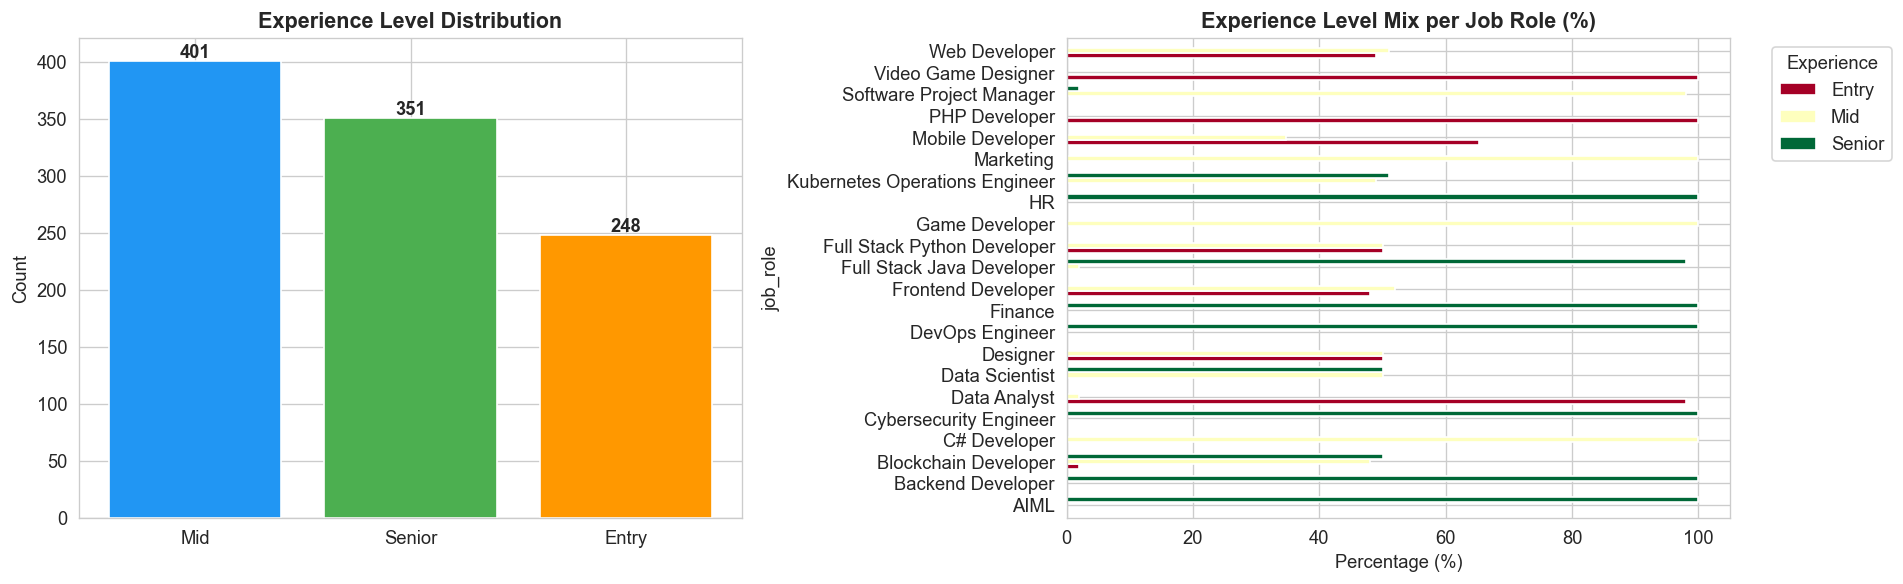

In [47]:
# Clean experience level (there's a 'Entry,' typo in the data)
df_clean = df.copy()
df_clean['experience_level'] = df_clean['experience_level'].str.strip().str.rstrip(',')

exp_counts = df_clean['experience_level'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall distribution
colors_exp = ['#2196F3', '#4CAF50', '#FF9800']
axes[0].bar(exp_counts.index, exp_counts.values, color=colors_exp)
axes[0].set_title('Experience Level Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(exp_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Experience level per job role
exp_role = df_clean.groupby(['job_role', 'experience_level']).size().unstack(fill_value=0)
exp_role_pct = exp_role.div(exp_role.sum(axis=1), axis=0) * 100
exp_role_pct.plot(kind='barh', ax=axes[1], colormap='RdYlGn', width=0.7)
axes[1].set_title('Experience Level Mix per Job Role (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Percentage (%)')
axes[1].legend(title='Experience', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

### 3.3 Qualification Analysis

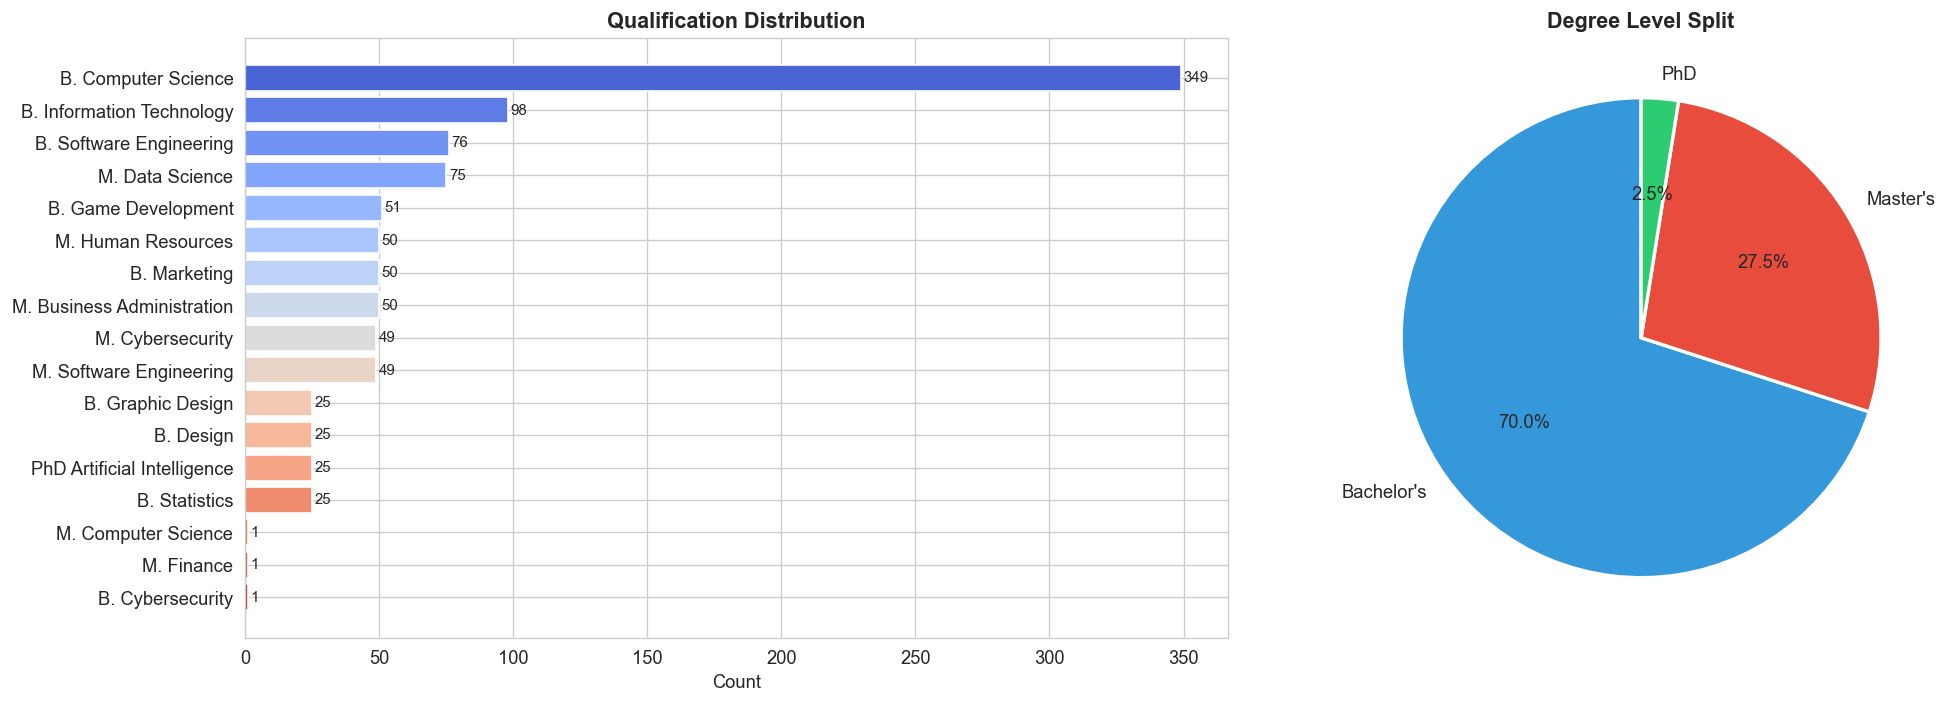


Degree level counts:
degree_level
Bachelor's    700
Master's      275
PhD            25
Name: count, dtype: int64


In [48]:
qual_counts = df_clean['qualification'].value_counts()

# Shorten labels for readability
short_labels = [q.replace("Bachelor's in ", "B. ").replace("Master's in ", "M. ").replace("PhD in ", "PhD ") 
                for q in qual_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar
bars = axes[0].barh(short_labels[::-1], qual_counts.values[::-1],
                    color=sns.color_palette('coolwarm', len(qual_counts))[::-1])
axes[0].set_xlabel('Count')
axes[0].set_title('Qualification Distribution', fontsize=13, fontweight='bold')
for i, v in enumerate(qual_counts.values[::-1]):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=9)

# Degree level breakdown (Bachelor's vs Master's vs PhD)
df_clean['degree_level'] = df_clean['qualification'].apply(
    lambda x: "PhD" if "PhD" in x else ("Master's" if "Master" in x else "Bachelor's")
)
deg_counts = df_clean['degree_level'].value_counts()
axes[1].pie(deg_counts.values, labels=deg_counts.index, autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c', '#2ecc71'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Degree Level Split', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDegree level counts:")
print(deg_counts)

### 3.4 Skills Analysis (NLP-based)

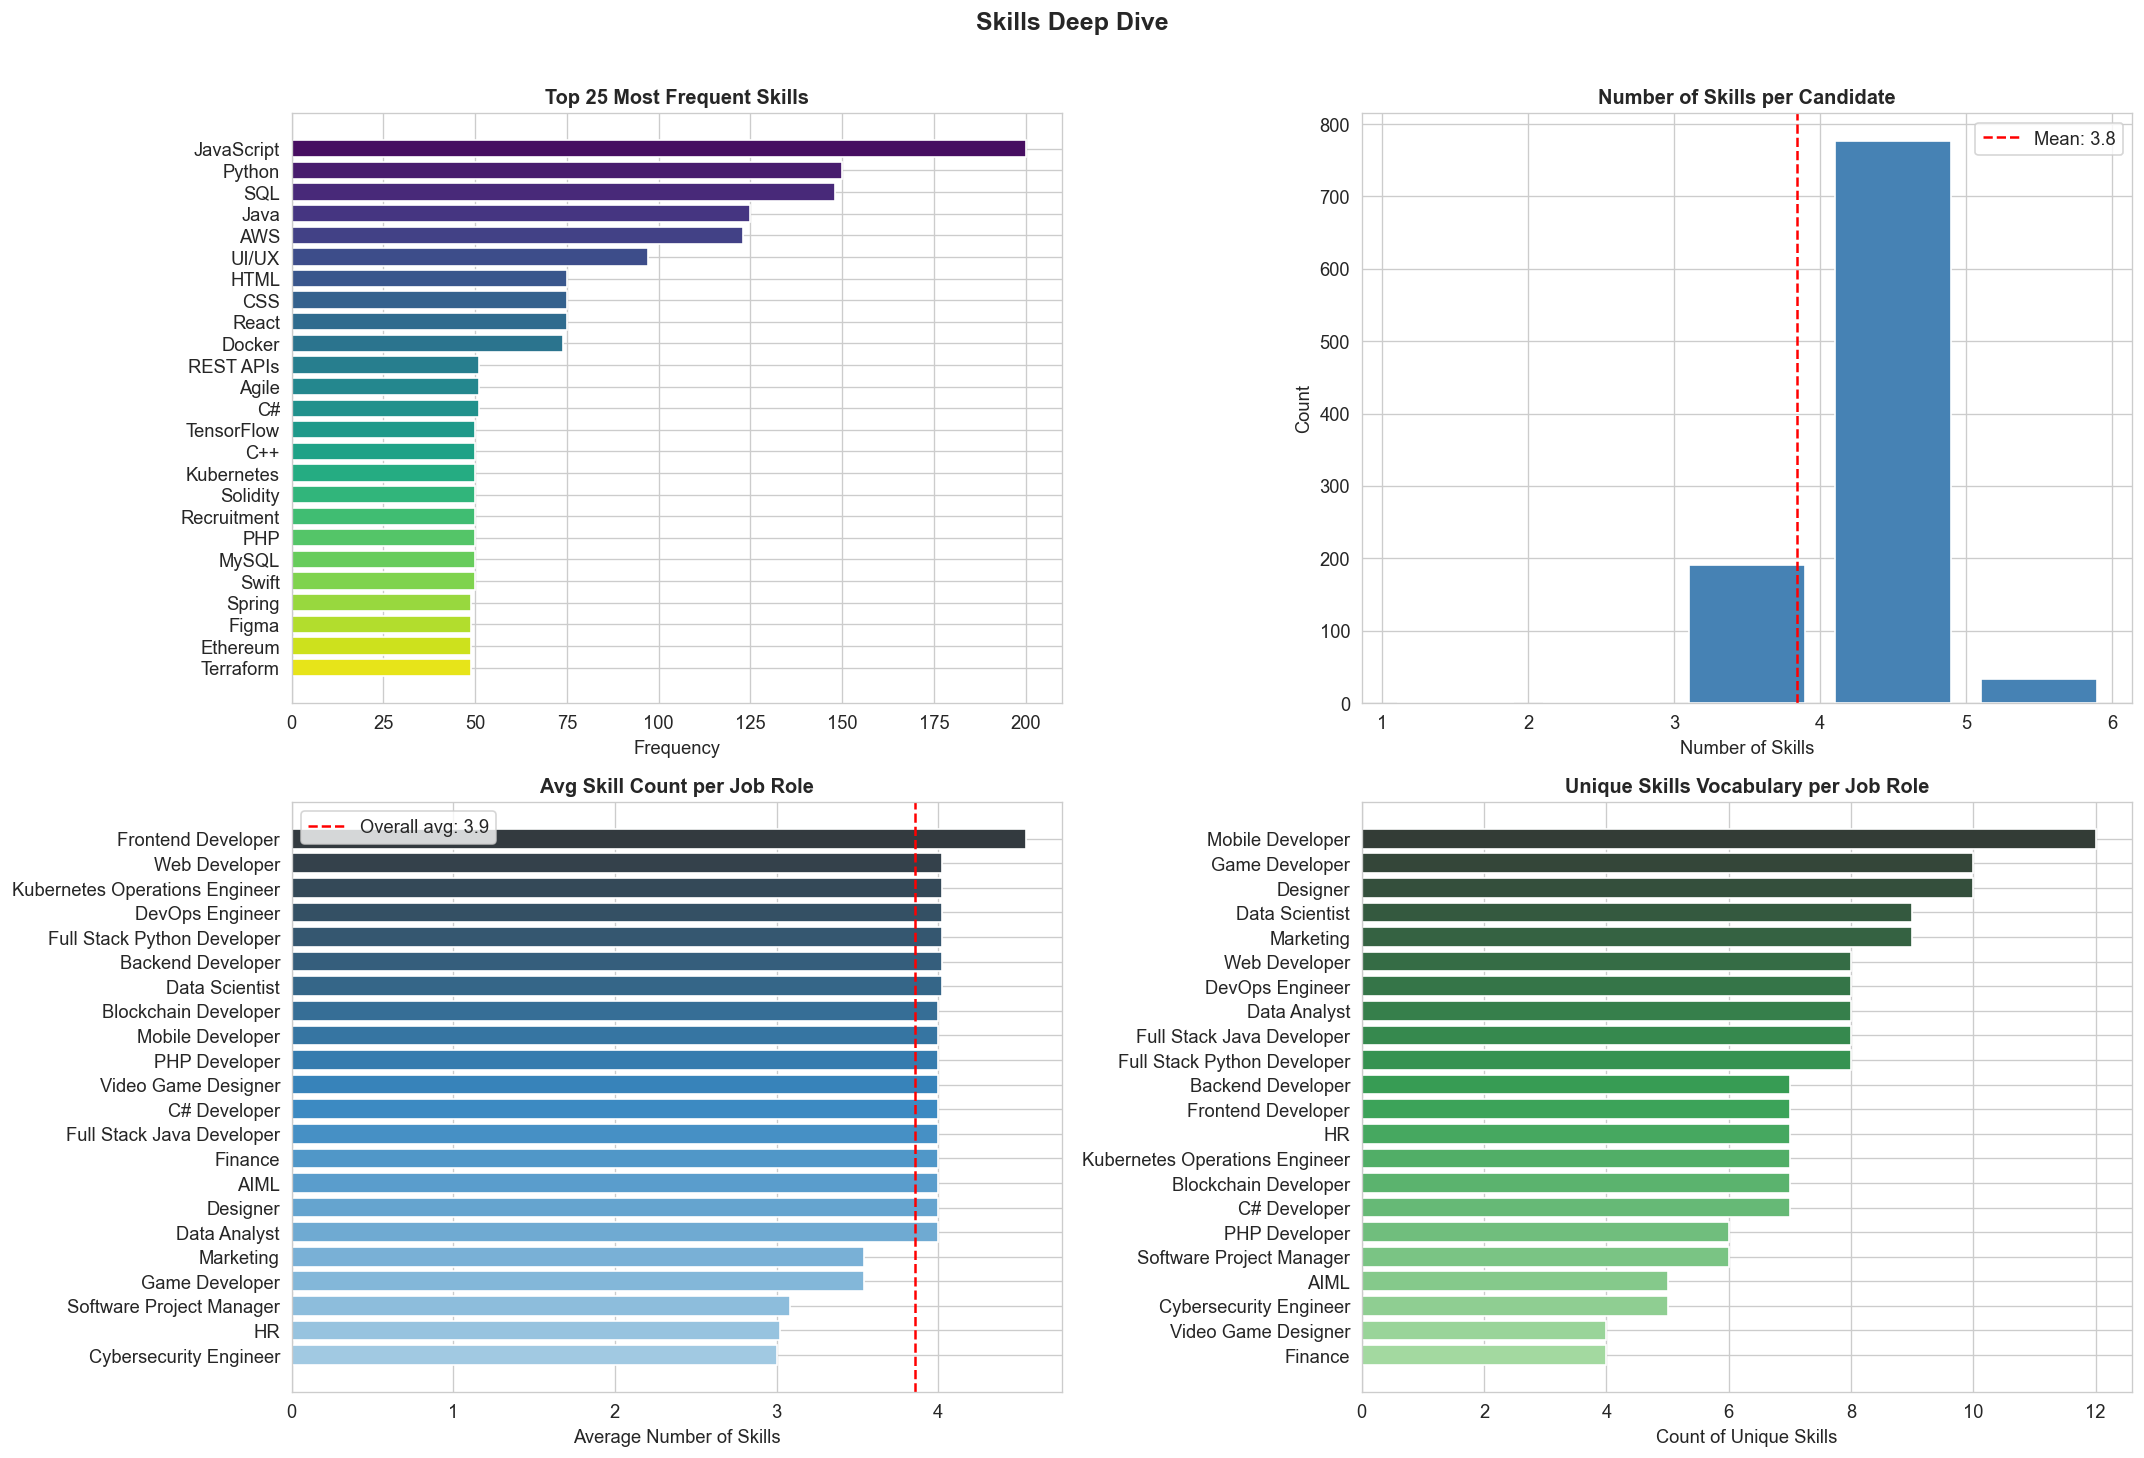


Total unique skills across dataset: 119
Average skills per candidate: 3.84


In [49]:
# Parse skills into lists
df_clean['skills_list'] = df_clean['skills'].apply(
    lambda x: [s.strip() for s in x.split(',')]
)
df_clean['skill_count'] = df_clean['skills_list'].apply(len)

# All individual skills
all_skills = [skill for skills in df_clean['skills_list'] for skill in skills]
skill_freq = Counter(all_skills)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top 25 most common skills
top25 = dict(sorted(skill_freq.items(), key=lambda x: x[1], reverse=True)[:25])
colors = sns.color_palette(PALETTE, 25)
axes[0, 0].barh(list(top25.keys())[::-1], list(top25.values())[::-1], color=colors[::-1])
axes[0, 0].set_title('Top 25 Most Frequent Skills', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Frequency')

# Skills per candidate (distribution)
axes[0, 1].hist(df_clean['skill_count'], bins=range(1, df_clean['skill_count'].max() + 2),
                color='steelblue', edgecolor='white', rwidth=0.8)
axes[0, 1].set_title('Number of Skills per Candidate', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Skills')
axes[0, 1].set_ylabel('Count')
axes[0, 1].axvline(df_clean['skill_count'].mean(), color='red', linestyle='--',
                    label=f"Mean: {df_clean['skill_count'].mean():.1f}")
axes[0, 1].legend()

# Average skill count per job role
avg_skills = df_clean.groupby('job_role')['skill_count'].mean().sort_values()
axes[1, 0].barh(avg_skills.index, avg_skills.values,
                color=sns.color_palette('Blues_d', len(avg_skills)))
axes[1, 0].set_title('Avg Skill Count per Job Role', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Average Number of Skills')
axes[1, 0].axvline(avg_skills.mean(), color='red', linestyle='--',
                    label=f'Overall avg: {avg_skills.mean():.1f}')
axes[1, 0].legend()

# Unique skills count
unique_skills_per_role = df_clean.groupby('job_role')['skills_list'].apply(
    lambda x: len(set([s for skills in x for s in skills]))
).sort_values()
axes[1, 1].barh(unique_skills_per_role.index, unique_skills_per_role.values,
                color=sns.color_palette('Greens_d', len(unique_skills_per_role)))
axes[1, 1].set_title('Unique Skills Vocabulary per Job Role', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Count of Unique Skills')

plt.suptitle('Skills Deep Dive', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nTotal unique skills across dataset: {len(skill_freq)}")
print(f"Average skills per candidate: {df_clean['skill_count'].mean():.2f}")

In [50]:
print("Top 5 skills per job role:")
print("=" * 70)
for role in sorted(df_clean['job_role'].unique()):
    role_skills = [
        s for skills in df_clean[df_clean['job_role'] == role]['skills_list']
        for s in skills
    ]
    top5 = Counter(role_skills).most_common(5)
    skills_str = ', '.join([f"{s}({c})" for s, c in top5])
    print(f"  {role:35s}: {skills_str}")

Top 5 skills per job role:
  AIML                               : Python(25), Deep Learning(25), NLP(25), TensorFlow(24), Machine Learning(1)
  Backend Developer                  : Java(50), SQL(50), REST APIs(26), Spring(25), Hibernate(25)
  Blockchain Developer               : Solidity(50), Ethereum(49), Web3(48), Blockchain(26), JavaScript(25)
  C# Developer                       : C#(50), Azure(49), SQL Server(49), ASP.NET(25), .NET Core(25)
  Cybersecurity Engineer             : SIEM(48), Network Security(27), Penetration Testing(26), Firewalls(25), Ethical Hacking(24)
  Data Analyst                       : SQL(50), Python(25), Pandas(25), Data Visualization(25), Tableau(25)
  Data Scientist                     : Python(50), TensorFlow(26), Machine Learning(26), SQL(25), Keras(25)
  Designer                           : Figma(49), UI/UX(48), Adobe XD(25), Prototyping(25), Sketch(24)
  DevOps Engineer                    : AWS(50), Jenkins(49), Terraform(47), Docker(26), Linux(25)
  

### 3.5 Cross-Feature Analysis

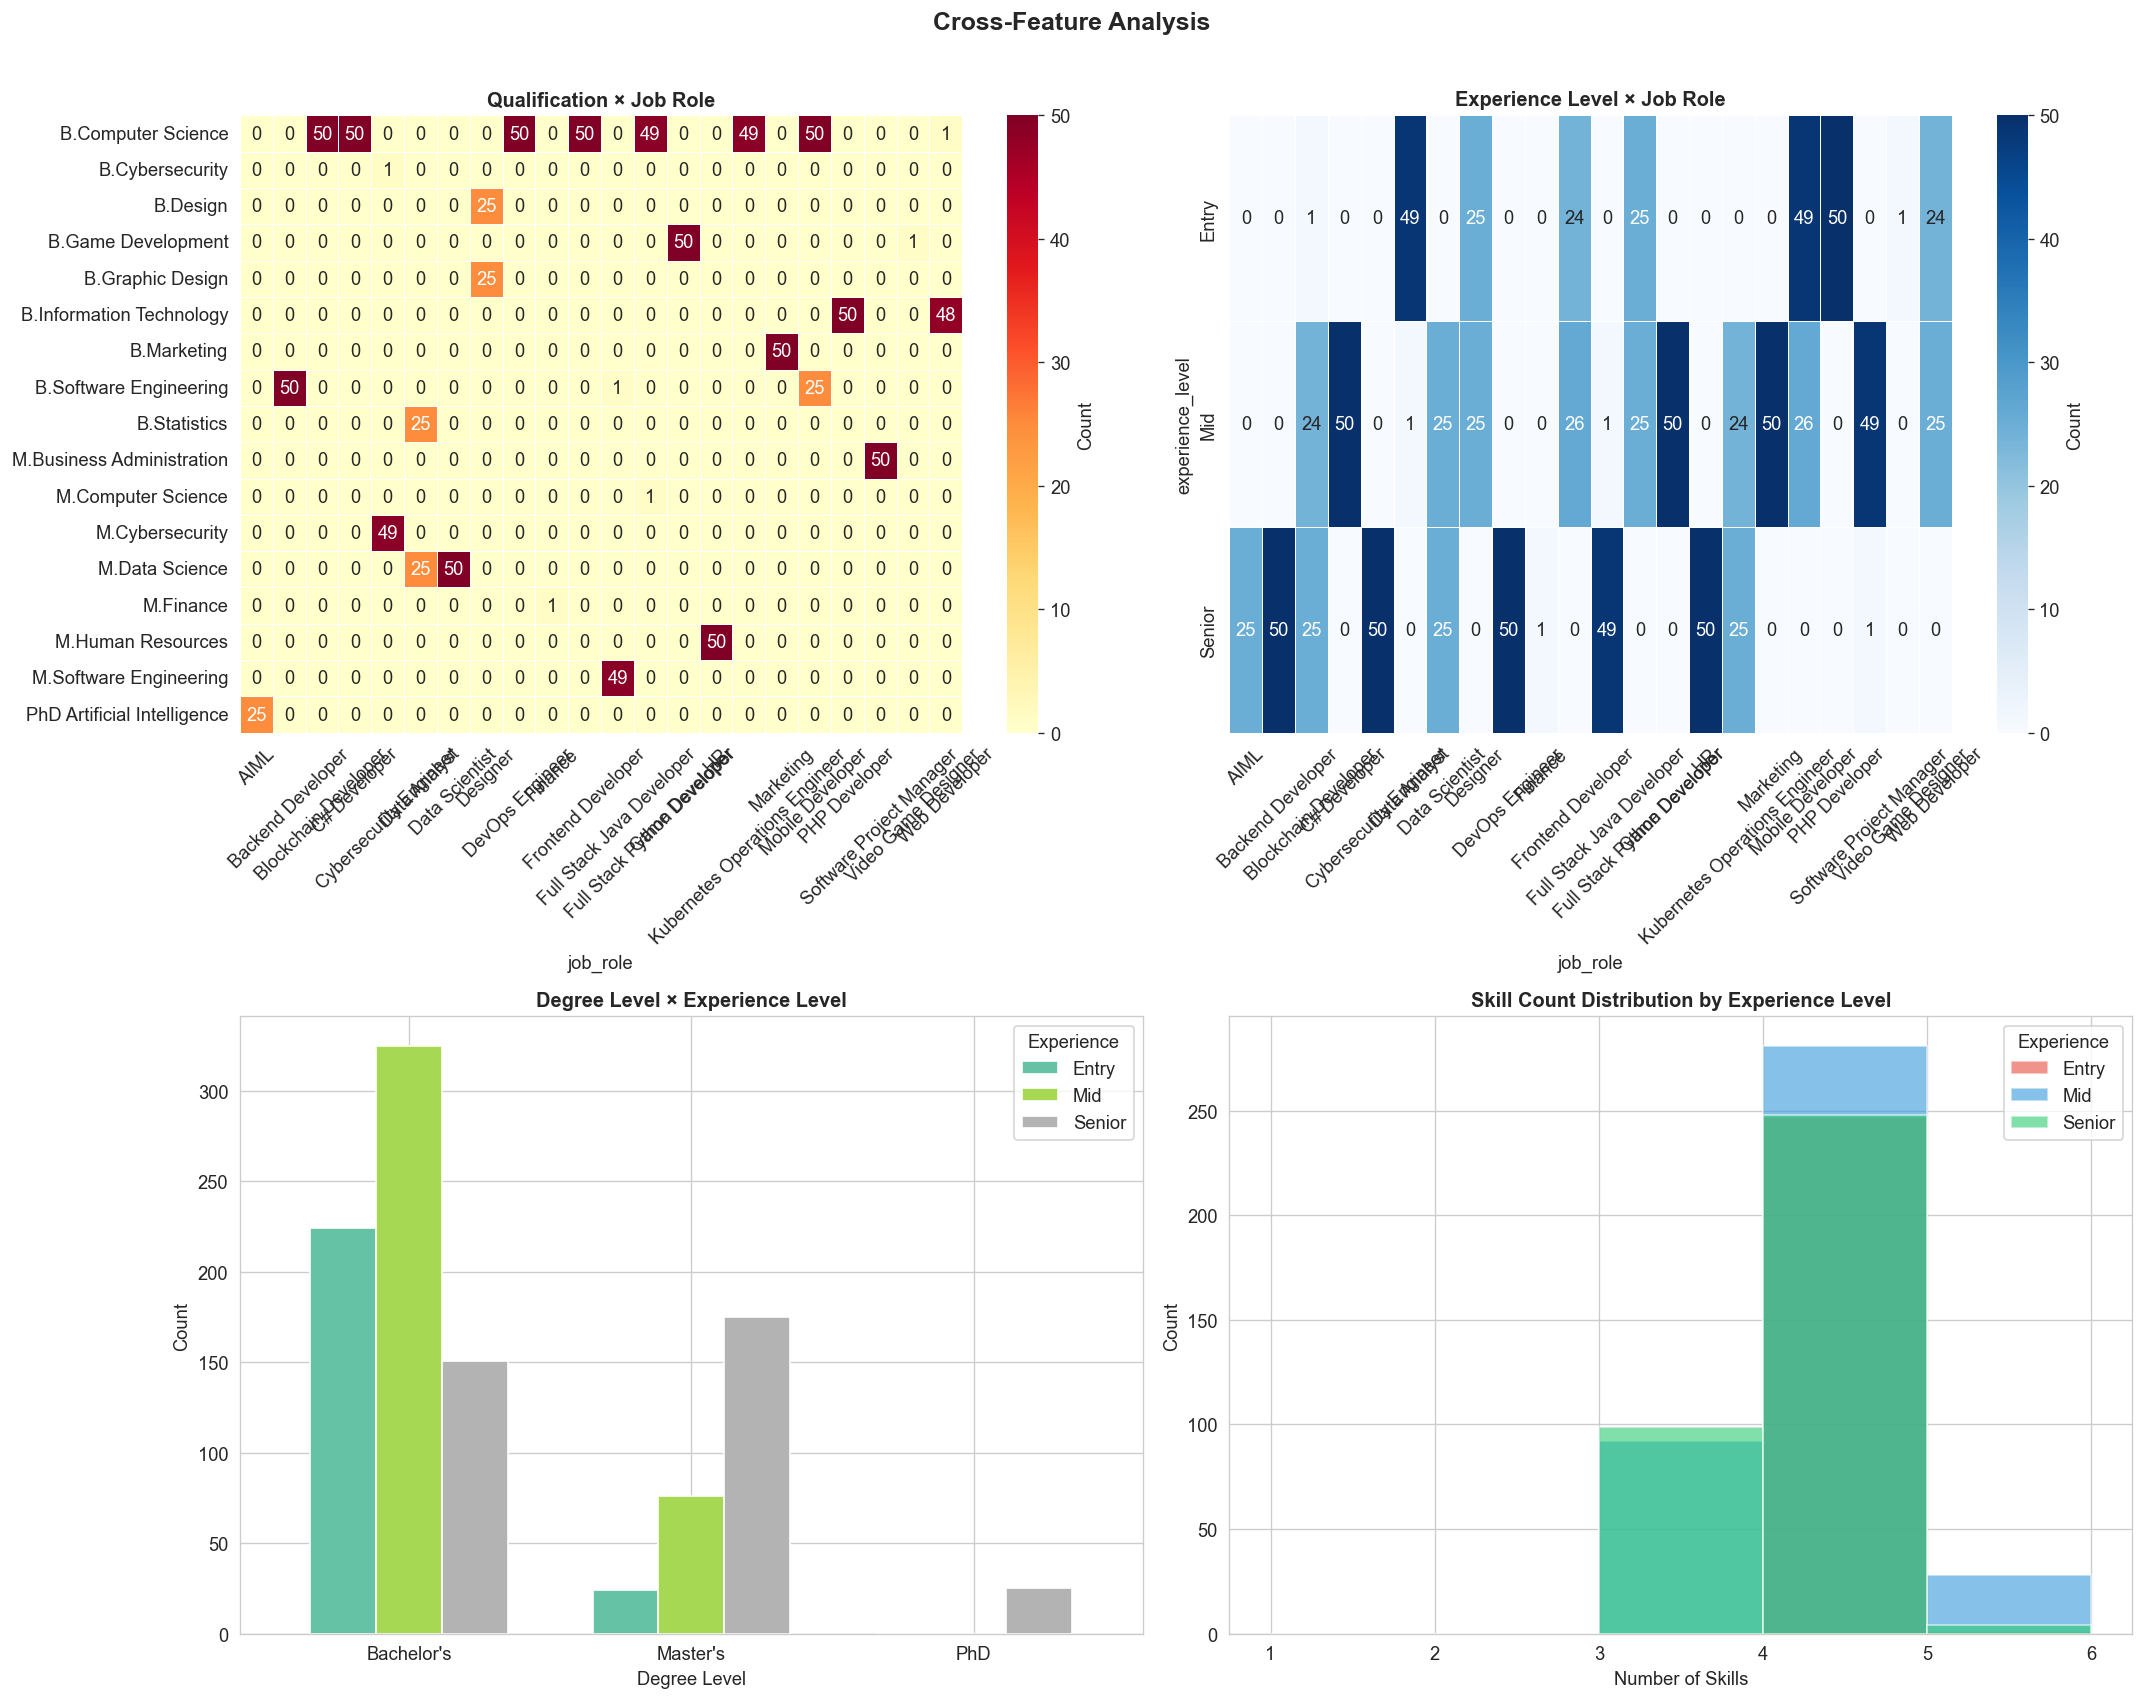

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Qualification x Job Role heatmap
qual_role = pd.crosstab(df_clean['qualification'], df_clean['job_role'])
# Shorten qual labels
qual_role.index = [q.replace("Bachelor's in ", "B.").replace("Master's in ", "M.").replace("PhD in ", "PhD ") 
                   for q in qual_role.index]
sns.heatmap(qual_role, ax=axes[0, 0], cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.5, cbar_kws={'label': 'Count'})
axes[0, 0].set_title('Qualification × Job Role', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].tick_params(axis='y', rotation=0)

# 2. Experience x Job Role heatmap
exp_role2 = pd.crosstab(df_clean['experience_level'], df_clean['job_role'])
sns.heatmap(exp_role2, ax=axes[0, 1], cmap='Blues', annot=True, fmt='d',
            linewidths=0.5, cbar_kws={'label': 'Count'})
axes[0, 1].set_title('Experience Level × Job Role', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Degree level x Experience
deg_exp = pd.crosstab(df_clean['degree_level'], df_clean['experience_level'])
deg_exp.plot(kind='bar', ax=axes[1, 0], colormap='Set2', width=0.7, edgecolor='white')
axes[1, 0].set_title('Degree Level × Experience Level', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Degree Level')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(title='Experience')
axes[1, 0].tick_params(axis='x', rotation=0)

# 4. Skill count distribution per experience level
for exp, color in zip(['Entry', 'Mid', 'Senior'], ['#e74c3c', '#3498db', '#2ecc71']):
    data = df_clean[df_clean['experience_level'] == exp]['skill_count']
    axes[1, 1].hist(data, bins=range(1, data.max() + 2), alpha=0.6,
                    label=exp, color=color, edgecolor='white')
axes[1, 1].set_title('Skill Count Distribution by Experience Level', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Number of Skills')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(title='Experience')

plt.suptitle('Cross-Feature Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.6 Skill Co-occurrence Heatmap

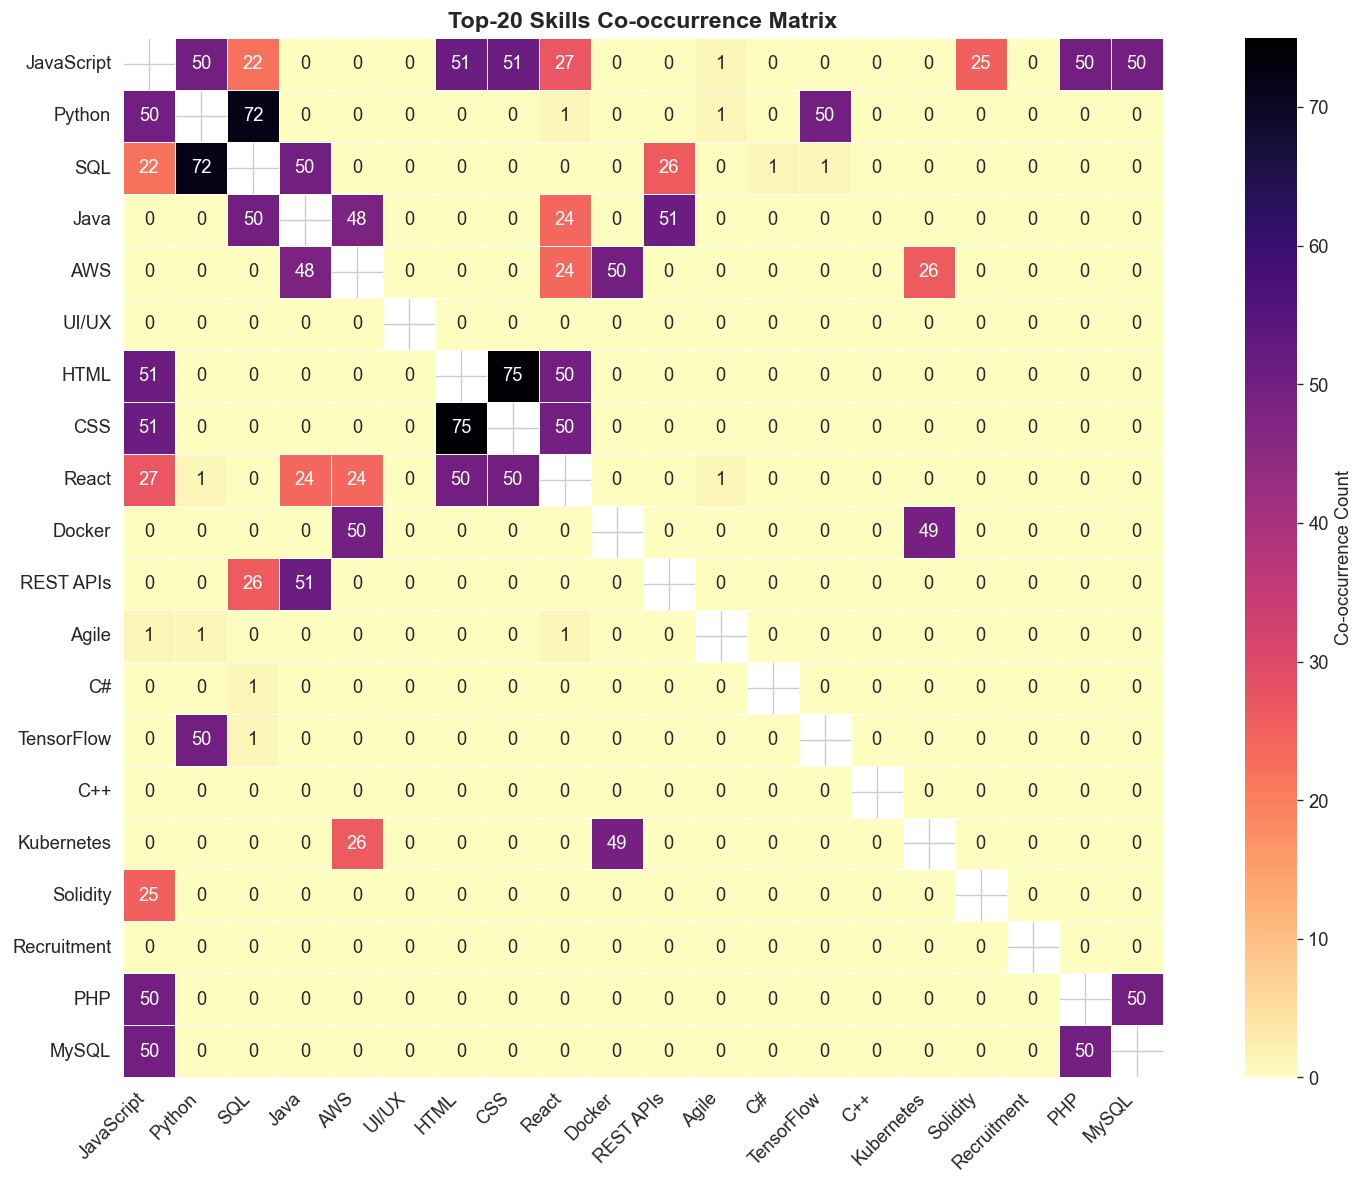

In [13]:
# Find top 20 skills and build co-occurrence matrix
top20_skills = [s for s, _ in skill_freq.most_common(20)]

cooccurrence = pd.DataFrame(0, index=top20_skills, columns=top20_skills)

for skills_list in df_clean['skills_list']:
    relevant = [s for s in skills_list if s in top20_skills]
    for s1, s2 in combinations(relevant, 2):
        cooccurrence.loc[s1, s2] += 1
        cooccurrence.loc[s2, s1] += 1

plt.figure(figsize=(14, 10))
mask = np.eye(len(top20_skills), dtype=bool)  # Hide diagonal
sns.heatmap(cooccurrence, cmap='magma_r', mask=mask, annot=True, fmt='d',
            linewidths=0.3, square=True, cbar_kws={'label': 'Co-occurrence Count'})
plt.title('Top-20 Skills Co-occurrence Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Data Cleaning & Preprocessing

In [14]:
print("=== Data Cleaning ===")

df_proc = df.copy()

# 1. Drop ID column
df_proc.drop('candidate_id', axis=1, inplace=True)

# 2. Strip whitespace and fix typos in categorical columns
for col in ['qualification', 'experience_level', 'job_role']:
    df_proc[col] = df_proc[col].str.strip().str.rstrip(',')
    print(f"  {col}: {df_proc[col].nunique()} unique values after cleaning")

# 3. Handle rare classes (Finance=1, Video Game Designer=1)
role_counts = df_proc['job_role'].value_counts()
rare_roles = role_counts[role_counts < 5].index.tolist()
print(f"\nRare job roles (< 5 samples): {rare_roles}")
df_proc = df_proc[~df_proc['job_role'].isin(rare_roles)]
print(f"Dataset shape after removing rare classes: {df_proc.shape}")

print(f"\nFinal class count: {df_proc['job_role'].nunique()} job roles")
print(df_proc['job_role'].value_counts())

=== Data Cleaning ===
  qualification: 17 unique values after cleaning
  experience_level: 3 unique values after cleaning
  job_role: 22 unique values after cleaning

Rare job roles (< 5 samples): ['Finance', 'Video Game Designer']
Dataset shape after removing rare classes: (998, 4)

Final class count: 20 job roles
job_role
Mobile Developer                  75
Data Scientist                    50
Backend Developer                 50
Frontend Developer                50
Designer                          50
Full Stack Python Developer       50
DevOps Engineer                   50
Game Developer                    50
Blockchain Developer              50
Marketing                         50
HR                                50
Full Stack Java Developer         50
C# Developer                      50
PHP Developer                     50
Cybersecurity Engineer            50
Software Project Manager          50
Data Analyst                      50
Kubernetes Operations Engineer    49
Web Deve

## 5. Feature Engineering

In [27]:
print("=== Feature Engineering ===")

# ── Approach: combine TF-IDF on skills text + label-encoded categorical features

# 1. Skills → TF-IDF features
#    Skills are comma-separated — treat them as a text "document"
def skill_tokenizer(x):
    return [s.strip() for s in x.split(',')]

tfidf = TfidfVectorizer(tokenizer=skill_tokenizer,
                         token_pattern=None, max_features=100)

X_skills = tfidf.fit_transform(df_proc['skills'])
print(f"Skills TF-IDF shape: {X_skills.shape}")

# 2. Encode experience_level (ordinal)
exp_map = {'Entry': 0, 'Mid': 1, 'Senior': 2}
df_proc['exp_encoded'] = df_proc['experience_level'].map(exp_map)

# 3. Encode qualification (label encoding is fine — no natural order)
le_qual = LabelEncoder()
df_proc['qual_encoded'] = le_qual.fit_transform(df_proc['qualification'])

# 4. Engineered numeric features
df_proc['skill_count'] = df_proc['skills'].apply(lambda x: len(x.split(',')))
df_proc['degree_level_num'] = df_proc['qualification'].apply(
    lambda x: 2 if 'PhD' in x else (1 if 'Master' in x else 0)
)

# 5. Combine all features
import scipy.sparse as sp
X_cat = df_proc[['exp_encoded', 'qual_encoded', 'skill_count', 'degree_level_num']].values
X_all = sp.hstack([X_skills, sp.csr_matrix(X_cat)])

# 6. Target
le_target = LabelEncoder()
y = le_target.fit_transform(df_proc['job_role'])

print(f"\nFinal feature matrix shape: {X_all.shape}")
print(f"Number of classes: {len(le_target.classes_)}")
print(f"Classes: {list(le_target.classes_)}")

# 7. Train/test split — stratified to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

=== Feature Engineering ===
Skills TF-IDF shape: (998, 100)

Final feature matrix shape: (998, 104)
Number of classes: 20
Classes: ['AIML', 'Backend Developer', 'Blockchain Developer', 'C# Developer', 'Cybersecurity Engineer', 'Data Analyst', 'Data Scientist', 'Designer', 'DevOps Engineer', 'Frontend Developer', 'Full Stack Java Developer', 'Full Stack Python Developer', 'Game Developer', 'HR', 'Kubernetes Operations Engineer', 'Marketing', 'Mobile Developer', 'PHP Developer', 'Software Project Manager', 'Web Developer']

Train size: 798, Test size: 200


## 6. Model Training & Evaluation

In [16]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test, cv=5):
    """Train model, evaluate with cross-val and test set, return metrics dict."""
    import time
    
    print(f"\n{'=' * 55}")
    print(f"  {name}")
    print(f"{'=' * 55}")
    
    # Cross-validation
    cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv_strategy,
                                scoring='accuracy', n_jobs=-1)
    print(f"  CV Accuracy:  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    # Fit
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0
    
    # Test predictions
    y_pred = model.predict(X_test)
    
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted')
    rec  = recall_score(y_test, y_pred, average='weighted')
    
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  F1 (weighted) : {f1:.4f}")
    print(f"  Precision     : {prec:.4f}")
    print(f"  Recall        : {rec:.4f}")
    print(f"  Training time : {train_time:.2f}s")
    
    return {
        'name': name,
        'model': model,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_acc': acc,
        'f1': f1,
        'precision': prec,
        'recall': rec,
        'train_time': train_time,
        'y_pred': y_pred
    }

In [19]:
results = []

# ── 1. Logistic Regression (baseline) ─────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
results.append(evaluate_model('Logistic Regression', lr,
                               X_train, X_test, y_train, y_test))

# ── 2. Random Forest ──────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=1,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
results.append(evaluate_model('Random Forest', rf,
                               X_train, X_test, y_train, y_test))

# ── 3. Extra Trees ────────────────────────────────────────────────────────────
et = ExtraTreesClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
results.append(evaluate_model('Extra Trees', et,
                               X_train, X_test, y_train, y_test))

# ── 4. Gradient Boosting ──────────────────────────────────────────────────────
gb = GradientBoostingClassifier(
    n_estimators=150, learning_rate=0.1, max_depth=5,
    random_state=RANDOM_STATE
)
results.append(evaluate_model('Gradient Boosting', gb,
                               X_train, X_test, y_train, y_test))

# ── 5. SVM ────────────────────────────────────────────────────────────────────
svm = SVC(C=10, kernel='rbf', probability=True,
           class_weight='balanced', random_state=RANDOM_STATE)
results.append(evaluate_model('SVM (RBF)', svm,
                               X_train, X_test, y_train, y_test))

# ── 6. XGBoost (if available) ─────────────────────────────────────────────────
if XGBOOST_AVAILABLE:
    xgb = XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1
    )
    results.append(evaluate_model('XGBoost', xgb,
                                   X_train, X_test, y_train, y_test))
else:
    print("\n⚠️  XGBoost skipped (not installed). Run: pip install xgboost")

# ── 7. LightGBM (if available) ────────────────────────────────────────────────
if LGBM_AVAILABLE:
    lgbm = LGBMClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=7,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
        verbose=-1
    )
    results.append(evaluate_model('LightGBM', lgbm,
                                   X_train, X_test, y_train, y_test))
else:
    print("\n⚠️  LightGBM skipped (not installed). Run: pip install lightgbm")


  Logistic Regression
  CV Accuracy:  0.9962 ± 0.0050
  Test Accuracy : 0.9900
  F1 (weighted) : 0.9900
  Precision     : 0.9909
  Recall        : 0.9900
  Training time : 0.53s

  Random Forest
  CV Accuracy:  0.9950 ± 0.0073
  Test Accuracy : 0.9900
  F1 (weighted) : 0.9899
  Precision     : 0.9908
  Recall        : 0.9900
  Training time : 0.41s

  Extra Trees
  CV Accuracy:  0.9950 ± 0.0047
  Test Accuracy : 0.9900
  F1 (weighted) : 0.9900
  Precision     : 0.9909
  Recall        : 0.9900
  Training time : 0.28s

  Gradient Boosting
  CV Accuracy:  0.9912 ± 0.0064
  Test Accuracy : 0.9800
  F1 (weighted) : 0.9797
  Precision     : 0.9821
  Recall        : 0.9800
  Training time : 2.40s

  SVM (RBF)
  CV Accuracy:  0.9962 ± 0.0050
  Test Accuracy : 0.9900
  F1 (weighted) : 0.9899
  Precision     : 0.9908
  Recall        : 0.9900
  Training time : 0.04s

  XGBoost
  CV Accuracy:  0.9862 ± 0.0073
  Test Accuracy : 0.9900
  F1 (weighted) : 0.9899
  Precision     : 0.9908
  Recall     

## 7. Model Comparison

In [20]:
# Summary table
results_df = pd.DataFrame([{
    'Model': r['name'],
    'CV Accuracy': f"{r['cv_mean']:.4f} ± {r['cv_std']:.4f}",
    'Test Accuracy': r['test_acc'],
    'F1 (weighted)': r['f1'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'Train Time (s)': f"{r['train_time']:.2f}"
} for r in results])

results_df = results_df.sort_values('Test Accuracy', ascending=False)
print("\n📊 Model Comparison Summary")
print("=" * 90)
print(results_df.to_string(index=False))


📊 Model Comparison Summary
              Model     CV Accuracy  Test Accuracy  F1 (weighted)  Precision  Recall Train Time (s)
Logistic Regression 0.9962 ± 0.0050           0.99       0.989975   0.990909    0.99           0.53
      Random Forest 0.9950 ± 0.0073           0.99       0.989937   0.990767    0.99           0.41
        Extra Trees 0.9950 ± 0.0047           0.99       0.989975   0.990909    0.99           0.28
          SVM (RBF) 0.9962 ± 0.0050           0.99       0.989937   0.990767    0.99           0.04
            XGBoost 0.9862 ± 0.0073           0.99       0.989937   0.990767    0.99           0.68
           LightGBM 0.9900 ± 0.0031           0.99       0.989937   0.990767    0.99           0.81
  Gradient Boosting 0.9912 ± 0.0064           0.98       0.979732   0.982086    0.98           2.40


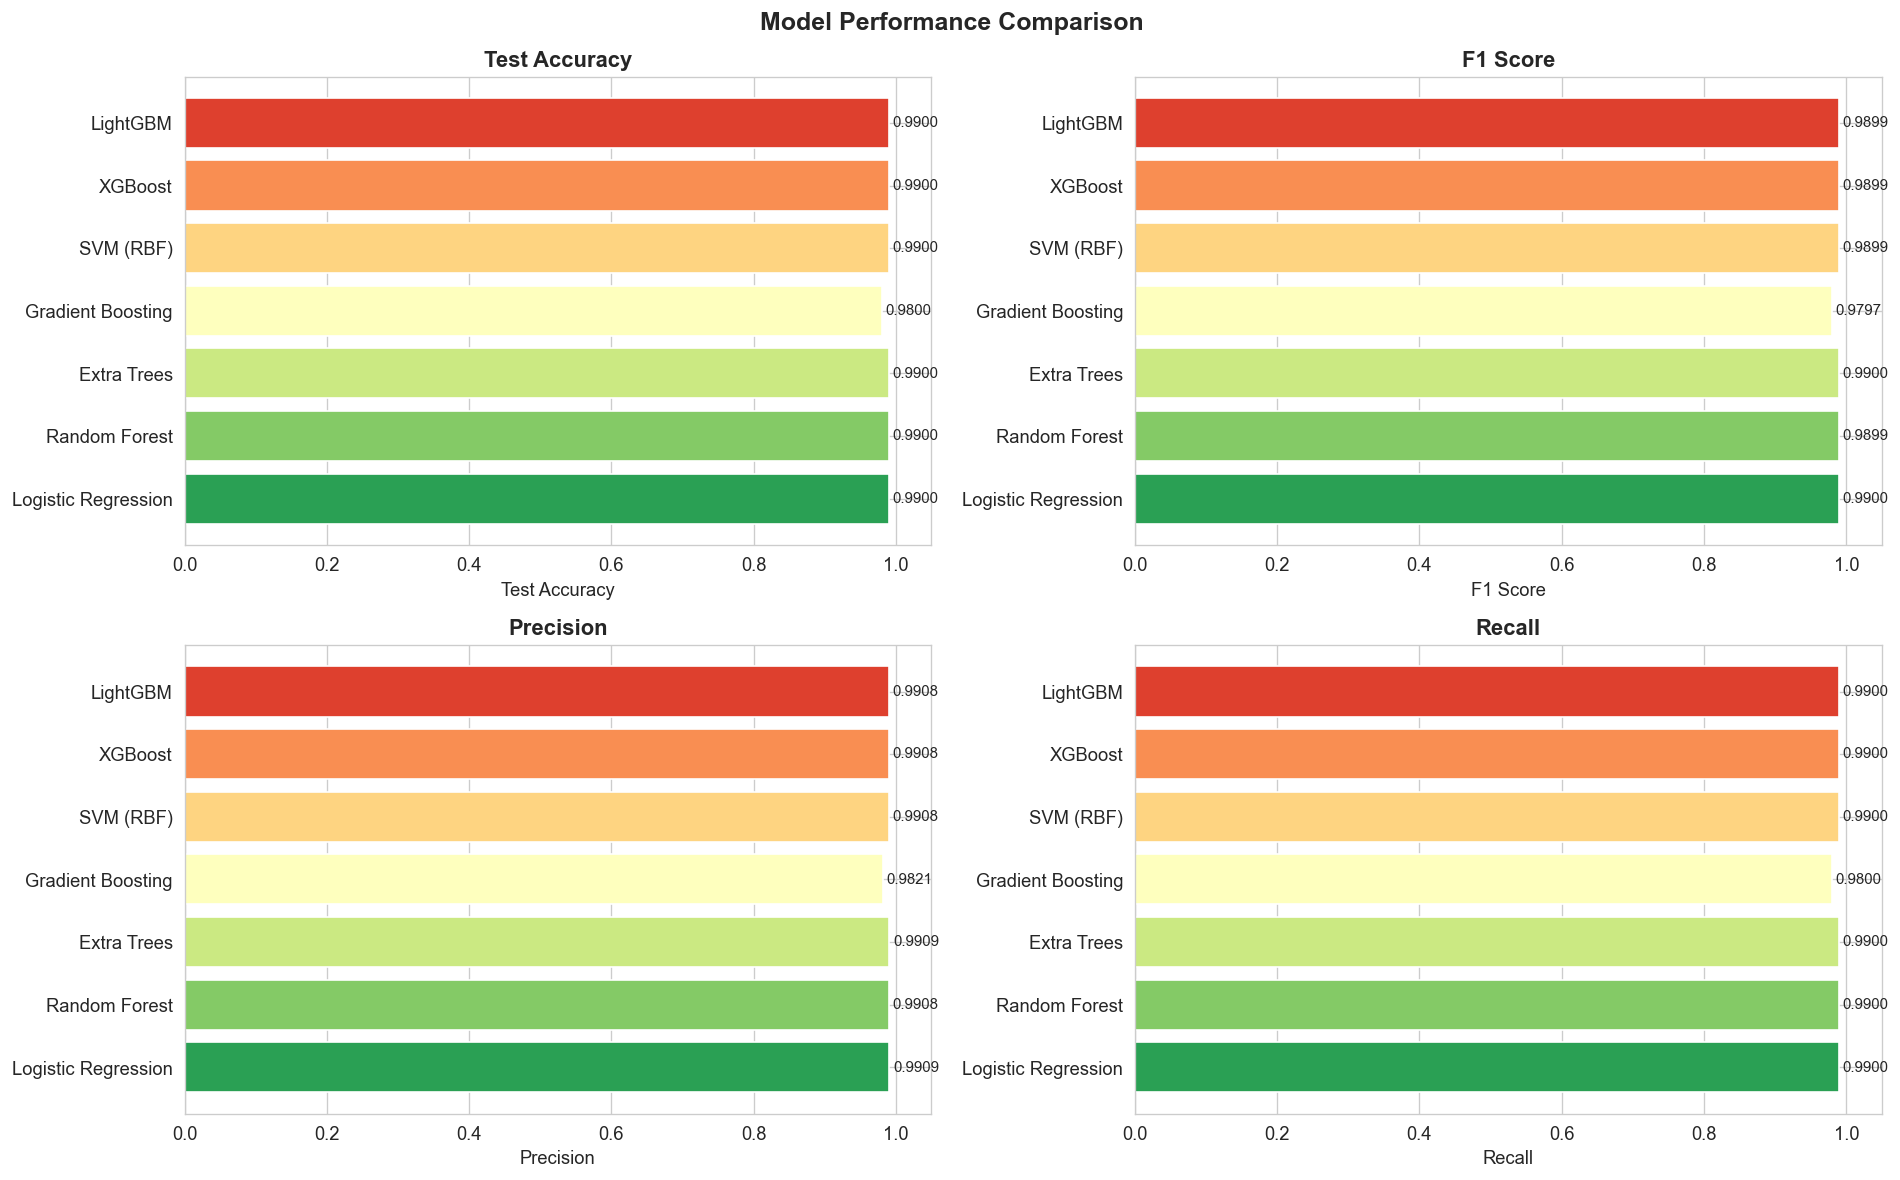

In [21]:
# Visualization
metrics = ['test_acc', 'f1', 'precision', 'recall']
metric_labels = ['Test Accuracy', 'F1 Score', 'Precision', 'Recall']
model_names = [r['name'] for r in results]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, metric, label in zip(axes.flatten(), metrics, metric_labels):
    values = [r[metric] for r in results]
    bars = ax.barh(model_names, values,
                   color=sns.color_palette('RdYlGn', len(model_names))
                         [::-1][:len(model_names)])
    ax.set_xlim(0, 1.05)
    ax.set_xlabel(label)
    ax.set_title(label, fontweight='bold')
    for bar, val in zip(bars, values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

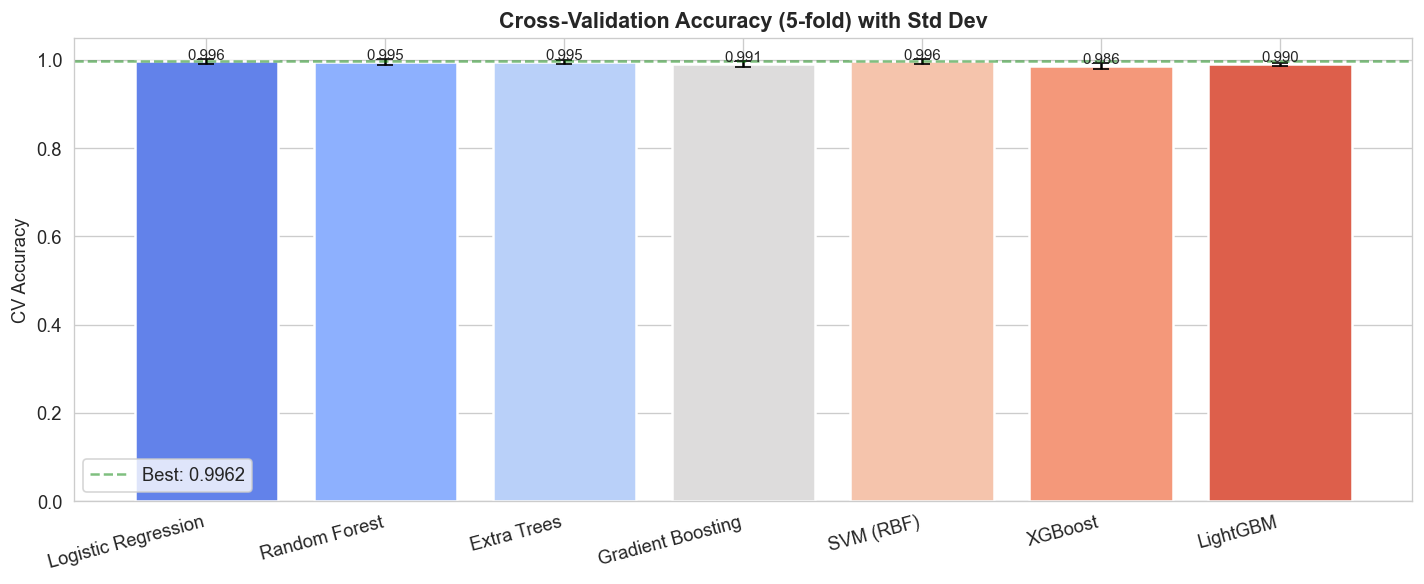

In [22]:
# CV score comparison with error bars
fig, ax = plt.subplots(figsize=(12, 5))
cv_means = [r['cv_mean'] for r in results]
cv_stds  = [r['cv_std']  for r in results]

x = np.arange(len(results))
bars = ax.bar(x, cv_means, yerr=cv_stds, capsize=5,
              color=sns.color_palette('coolwarm', len(results)),
              edgecolor='white', linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels([r['name'] for r in results], rotation=15, ha='right')
ax.set_ylabel('CV Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Cross-Validation Accuracy (5-fold) with Std Dev', fontsize=13, fontweight='bold')
ax.axhline(max(cv_means), color='green', linestyle='--', alpha=0.5,
            label=f'Best: {max(cv_means):.4f}')
ax.legend()
for bar, val in zip(bars, cv_means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Best Model Analysis

In [23]:
# Find best model
best = max(results, key=lambda r: r['test_acc'])
print(f"🏆 Best Model: {best['name']}")
print(f"   Test Accuracy : {best['test_acc']:.4f}")
print(f"   F1 (weighted) : {best['f1']:.4f}")

# Full classification report
print(f"\n--- Classification Report ({best['name']}) ---")
print(classification_report(y_test, best['y_pred'],
                             target_names=le_target.classes_))

🏆 Best Model: Logistic Regression
   Test Accuracy : 0.9900
   F1 (weighted) : 0.9900

--- Classification Report (Logistic Regression) ---
                                precision    recall  f1-score   support

                          AIML       1.00      1.00      1.00         5
             Backend Developer       0.91      1.00      0.95        10
          Blockchain Developer       1.00      1.00      1.00        10
                  C# Developer       1.00      1.00      1.00        10
        Cybersecurity Engineer       1.00      1.00      1.00        10
                  Data Analyst       1.00      1.00      1.00        10
                Data Scientist       1.00      1.00      1.00        10
                      Designer       1.00      1.00      1.00        10
               DevOps Engineer       1.00      0.90      0.95        10
            Frontend Developer       1.00      1.00      1.00        10
     Full Stack Java Developer       1.00      0.90      0.95       

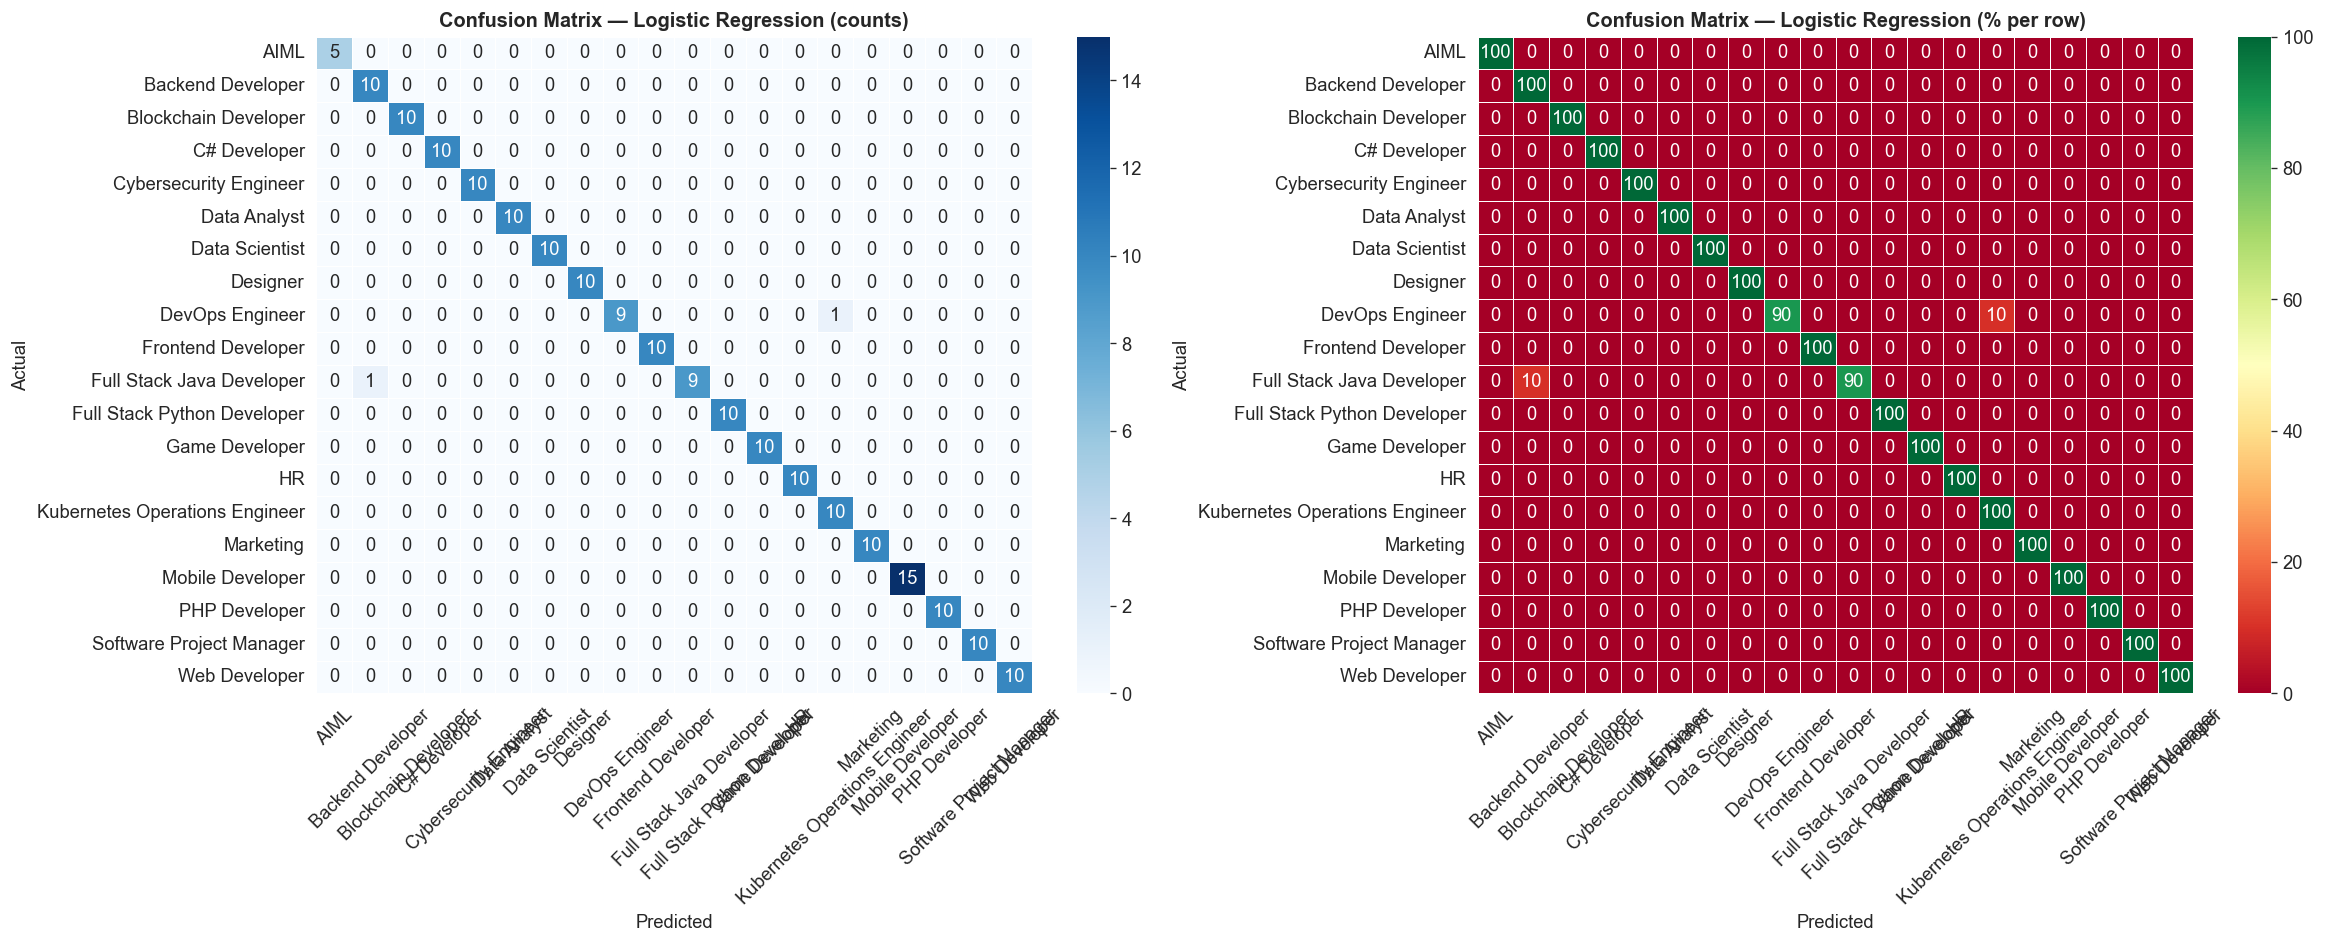

In [24]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, best['y_pred'])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le_target.classes_, yticklabels=le_target.classes_,
            linewidths=0.3)
axes[0].set_title(f'Confusion Matrix — {best["name"]} (counts)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

# Percentage
sns.heatmap(cm_pct, annot=True, fmt='.0f', cmap='RdYlGn', ax=axes[1],
            xticklabels=le_target.classes_, yticklabels=le_target.classes_,
            linewidths=0.3, vmin=0, vmax=100)
axes[1].set_title(f'Confusion Matrix — {best["name"]} (% per row)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [25]:
# Feature importance (if model supports it)
best_model = best['model']

if hasattr(best_model, 'feature_importances_'):
    # Get feature names: TF-IDF features + our engineered features
    tfidf_features = tfidf.get_feature_names_out().tolist()
    extra_features = ['exp_encoded', 'qual_encoded', 'skill_count', 'degree_level_num']
    all_features = tfidf_features + extra_features
    
    importances = pd.Series(best_model.feature_importances_, index=all_features)
    top_features = importances.nlargest(25)
    
    plt.figure(figsize=(10, 8))
    colors = ['#e74c3c' if f in extra_features else '#3498db' for f in top_features.index]
    top_features[::-1].plot(kind='barh', color=colors[::-1])
    plt.title(f'Top 25 Feature Importances — {best["name"]}',
              fontsize=13, fontweight='bold')
    plt.xlabel('Importance')
    
    # Legend
    blue_patch = mpatches.Patch(color='#3498db', label='TF-IDF Skill Features')
    red_patch  = mpatches.Patch(color='#e74c3c', label='Engineered Features')
    plt.legend(handles=[blue_patch, red_patch])
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Feature importance not available for {best['name']}")

Feature importance not available for Logistic Regression


## 9. Save Best Model

In [52]:
# Save model and all required artifacts
os.makedirs('model_artifacts', exist_ok=True)

# Bundle everything needed for inference
model_bundle = {
    'model': best_model,
    'tfidf': tfidf,
    'le_qual': le_qual,
    'le_target': le_target,
    'exp_map': exp_map,
    'model_name': best['name'],
    'test_accuracy': best['test_acc'],
    'f1_score': best['f1'],
    'classes': list(le_target.classes_)
}

# ── Save as joblib (recommended for sklearn models) ───────────────────────────
joblib_path = 'model_artifacts/job_role_predictor.joblib'
joblib.dump(model_bundle, joblib_path)
print(f"+ Saved with joblib: {joblib_path}")

# ── Save as pickle ────────────────────────────────────────────────────────────
pickle_path = 'model_artifacts/job_role_predictor.pkl'
with open(pickle_path, 'wb') as f:
    pickle.dump(model_bundle, f)
print(f"+ Saved with pickle: {pickle_path}")

# Show file sizes
for path in [joblib_path, pickle_path]:
    size_kb = os.path.getsize(path) / 1024
    print(f"   {path}: {size_kb:.1f} KB")

# ── Optional: save standalone XGBoost model ──────────────────────────────────
if best['name'] == 'XGBoost':
    xgb_json_path = 'model_artifacts/xgboost_model.json'
    best_model.save_model(xgb_json_path)
    print(f"+ Saved XGBoost native model: {xgb_json_path}")
else:
    xgb_standalone_path = 'model_artifacts/xgboost_model.joblib'
    joblib.dump(best_model, xgb_standalone_path)
    print(f"+ Saved standalone best model: {xgb_standalone_path}")

+ Saved with joblib: model_artifacts/job_role_predictor.joblib
+ Saved with pickle: model_artifacts/job_role_predictor.pkl
   model_artifacts/job_role_predictor.joblib: 23.6 KB
   model_artifacts/job_role_predictor.pkl: 22.9 KB


In [29]:
# ── Inference demo — load model and predict ───────────────────────────────────
import scipy.sparse as sp

def predict_job_role(skills: str, qualification: str, experience_level: str,
                     bundle_path: str = 'model_artifacts/job_role_predictor.joblib'):
    """
    Predict job role from candidate profile.
    
    Args:
        skills: comma-separated string, e.g. 'Python, SQL, TensorFlow'
        qualification: e.g. "Master's in Data Science"
        experience_level: 'Entry', 'Mid', or 'Senior'
    Returns:
        Predicted job role and top-3 probabilities
    """
    bundle = joblib.load(bundle_path)
    model   = bundle['model']
    tfidf   = bundle['tfidf']
    le_qual = bundle['le_qual']
    le_tgt  = bundle['le_target']
    exp_map = bundle['exp_map']

    # Feature engineering (same as training)
    skills_clean = ', '.join([s.strip() for s in skills.split(',')])
    X_tfidf = tfidf.transform([skills_clean])

    exp_enc = exp_map.get(experience_level.strip(), 1)  # default Mid
    try:
        qual_enc = le_qual.transform([qualification.strip()])[0]
    except ValueError:
        qual_enc = 0  # unknown qualification → 0

    skill_count = len(skills.split(','))
    degree_num  = 2 if 'PhD' in qualification else (1 if 'Master' in qualification else 0)

    X_cat = sp.csr_matrix([[exp_enc, qual_enc, skill_count, degree_num]])
    X = sp.hstack([X_tfidf, X_cat])

    pred_idx = model.predict(X)[0]
    pred_role = le_tgt.inverse_transform([pred_idx])[0]

    result = {'predicted_role': pred_role}

    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)[0]
        top3_idx = np.argsort(proba)[::-1][:3]
        result['top_3'] = [
            (le_tgt.inverse_transform([i])[0], round(proba[i], 4))
            for i in top3_idx
        ]

    return result


# Test predictions
test_candidates = [
    ('Python, SQL, TensorFlow, Machine Learning',    "Master's in Data Science",          'Senior'),
    ('HTML, CSS, JavaScript, React',                  "Bachelor's in Computer Science",     'Entry'),
    ('Kubernetes, Docker, AWS, CI/CD, Linux',          "Bachelor's in Computer Science",     'Senior'),
    ('Solidity, Ethereum, JavaScript, Blockchain',    "Bachelor's in Computer Science",     'Mid'),
    ('Figma, Adobe XD, UI/UX Design, Creativity',     "Bachelor's in Design",               'Entry'),
]

print("\n=== Inference Demo ===")
for skills, qual, exp in test_candidates:
    result = predict_job_role(skills, qual, exp)
    print(f"\nSkills: {skills[:45]}...")
    print(f"  → Predicted: {result['predicted_role']}")
    if 'top_3' in result:
        print(f"  → Top 3: {result['top_3']}")


=== Inference Demo ===

Skills: Python, SQL, TensorFlow, Machine Learning...
  → Predicted: Data Scientist
  → Top 3: [('Data Scientist', np.float64(0.8869)), ('HR', np.float64(0.0256)), ('Full Stack Java Developer', np.float64(0.0211))]

Skills: HTML, CSS, JavaScript, React...
  → Predicted: Frontend Developer
  → Top 3: [('Frontend Developer', np.float64(0.807)), ('Full Stack Python Developer', np.float64(0.0523)), ('Web Developer', np.float64(0.0476))]

Skills: Kubernetes, Docker, AWS, CI/CD, Linux...
  → Predicted: Kubernetes Operations Engineer
  → Top 3: [('Kubernetes Operations Engineer', np.float64(0.7182)), ('DevOps Engineer', np.float64(0.1756)), ('Blockchain Developer', np.float64(0.0277))]

Skills: Solidity, Ethereum, JavaScript, Blockchain...
  → Predicted: Blockchain Developer
  → Top 3: [('Blockchain Developer', np.float64(0.7861)), ('Full Stack Python Developer', np.float64(0.0452)), ('C# Developer', np.float64(0.0341))]

Skills: Figma, Adobe XD, UI/UX Design, Creativi

In [30]:
print("\n" + "=" * 60)
print("           PROJECT SUMMARY")
print("=" * 60)
print(f"  Dataset: {df_proc.shape[0]} candidates, {df_proc['job_role'].nunique()} job roles")
print(f"  Features: TF-IDF (skills) + 4 engineered features")
print(f"")
print(f"  Model Results:")
for r in sorted(results, key=lambda x: x['test_acc'], reverse=True):
    marker = ' 🏆' if r['name'] == best['name'] else ''
    print(f"    {r['name']:30s}: Acc={r['test_acc']:.4f}  F1={r['f1']:.4f}{marker}")
print(f"")
print(f"  Best Model: {best['name']}")
print(f"  Test Accuracy: {best['test_acc']:.4f}")
print(f"  Saved to: model_artifacts/")
print("=" * 60)


           PROJECT SUMMARY
  Dataset: 998 candidates, 20 job roles
  Features: TF-IDF (skills) + 4 engineered features

  Model Results:
    Logistic Regression           : Acc=0.9900  F1=0.9900 🏆
    Random Forest                 : Acc=0.9900  F1=0.9899
    Extra Trees                   : Acc=0.9900  F1=0.9900
    SVM (RBF)                     : Acc=0.9900  F1=0.9899
    XGBoost                       : Acc=0.9900  F1=0.9899
    LightGBM                      : Acc=0.9900  F1=0.9899
    Gradient Boosting             : Acc=0.9800  F1=0.9797

  Best Model: Logistic Regression
  Test Accuracy: 0.9900
  Saved to: model_artifacts/
